# Binary Classification with Logistic Regression
### Breast Cancer Wisconsin (Diagnostic) Dataset

**Objective:** Build a binary classifier that predicts whether a tumor is **Malignant (M)** or **Benign (B)** from digitized cell-nuclei measurements, using Logistic Regression.

**Tools:** Scikit-learn, Pandas, Matplotlib

**Steps covered:**
1. Load & explore the dataset
2. Train/test split and standardize features
3. Fit a Logistic Regression model
4. Evaluate with confusion matrix, precision, recall, ROC-AUC
5. Tune the classification threshold
6. Explain the sigmoid function


## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, precision_recall_curve, accuracy_score)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('data.csv')
print(df.shape)
df.head()


(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### About the dataset

Each row is a digitized image of a breast mass's fine needle aspirate (FNA), with 30 numeric features describing the cell nuclei present (mean, standard-error, and "worst"/largest value of radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension).

Target column: **`diagnosis`** — `M` = Malignant, `B` = Benign.

In [2]:
# Drop non-predictive / empty columns
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print(df['diagnosis'].value_counts())
print("\nClass balance:")
print(df['diagnosis'].value_counts(normalize=True).round(3))


diagnosis
B    357
M    212
Name: count, dtype: int64

Class balance:
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64


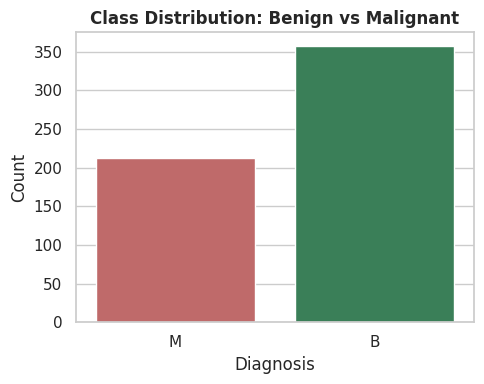

In [3]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette={'B':'seagreen','M':'indianred'}, legend=False)
plt.title('Class Distribution: Benign vs Malignant', fontweight='bold')
plt.xlabel('Diagnosis'); plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Note:** The classes are moderately imbalanced (~63% Benign / ~37% Malignant) but not severely so — logistic regression should handle this reasonably well, though we'll keep an eye on recall for the malignant (minority, and clinically critical) class.

## 2. Encode Target & Select Features

In [4]:
# Encode target: Malignant = 1 (positive class), Benign = 0
df['target'] = (df['diagnosis'] == 'M').astype(int)

X = df.drop(columns=['diagnosis', 'target'])
y = df['target']

print("Features:", X.shape[1])
print("Target distribution:", y.value_counts().to_dict())


Features: 30
Target distribution: {0: 357, 1: 212}


## 3. Train/Test Split & Standardization

Logistic Regression is sensitive to feature scale (it optimizes a linear combination of features before squashing through the sigmoid), so we **standardize** features to mean 0, std 1. We fit the scaler only on the training set to avoid data leakage.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (455, 30)  Test shape: (114, 30)
Train class balance:
 target
0    0.626
1    0.374
Name: proportion, dtype: float64
Test class balance:
 target
0    0.632
1    0.368
Name: proportion, dtype: float64


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Fit Logistic Regression Model

In [7]:
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of Malignant (class 1)

print("Model trained.")
print("Accuracy on test set:", round(accuracy_score(y_test, y_pred), 4))


Model trained.
Accuracy on test set: 0.9649


## 5. The Sigmoid Function — Why Logistic Regression Works

Logistic Regression first computes a **linear score** (like linear regression):

$$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

This `z` can be any real number from $-\infty$ to $+\infty$, so it isn't a valid probability yet. The **sigmoid (logistic) function** squashes `z` into the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- As $z \to +\infty$, $\sigma(z) \to 1$ (very confident positive class)
- As $z \to -\infty$, $\sigma(z) \to 0$ (very confident negative class)
- At $z = 0$, $\sigma(z) = 0.5$ (the default decision boundary)

The model predicts class **1 (Malignant)** if $\sigma(z) \geq \text{threshold}$ (default 0.5), else class **0 (Benign)**.

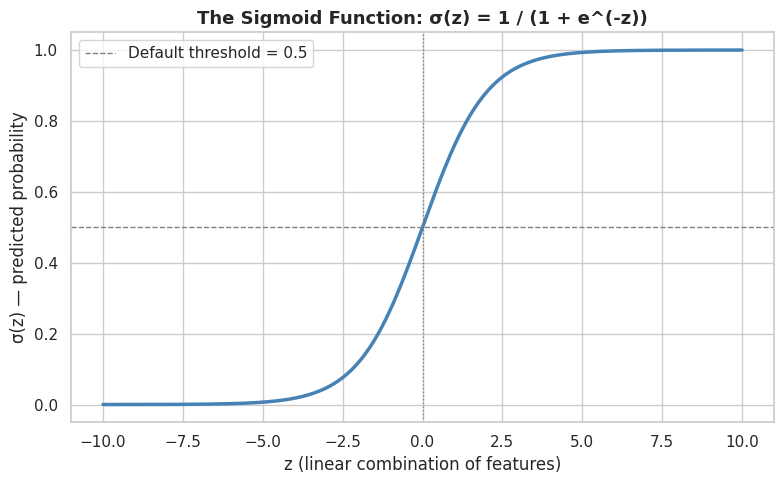

In [8]:
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8,5))
plt.plot(z, sigmoid, color='steelblue', linewidth=2.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold = 0.5')
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.title('The Sigmoid Function: σ(z) = 1 / (1 + e^(-z))', fontweight='bold', fontsize=13)
plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) — predicted probability')
plt.legend()
plt.tight_layout()
plt.show()


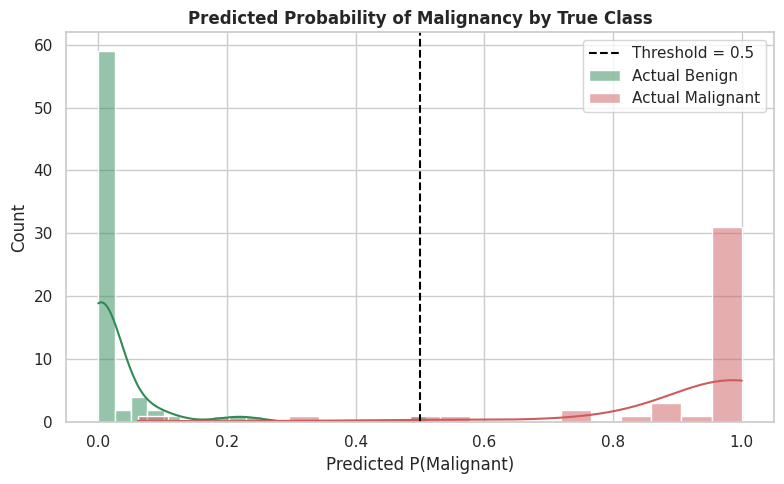

In [9]:
# Visualize the actual predicted probabilities for our test set
plt.figure(figsize=(8,5))
sns.histplot(y_proba[y_test==0], color='seagreen', label='Actual Benign', kde=True, alpha=0.5, bins=20)
sns.histplot(y_proba[y_test==1], color='indianred', label='Actual Malignant', kde=True, alpha=0.5, bins=20)
plt.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
plt.title('Predicted Probability of Malignancy by True Class', fontweight='bold')
plt.xlabel('Predicted P(Malignant)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Most Benign cases cluster near probability 0, and most Malignant cases cluster near probability 1 — the model separates the classes well, with only a few cases falling near the ambiguous 0.5 boundary.

## 6. Evaluation: Confusion Matrix

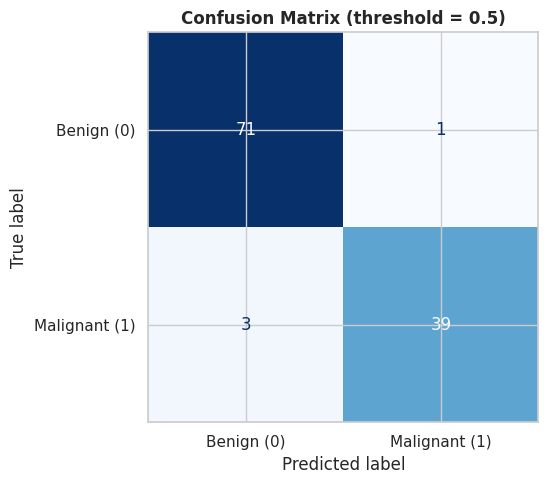

True Negatives (correct Benign):     71
False Positives (Benign called M):   1
False Negatives (Malignant called B):3  <-- most costly error clinically
True Positives (correct Malignant):  39


In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (threshold = 0.5)', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct Benign):     {tn}")
print(f"False Positives (Benign called M):   {fp}")
print(f"False Negatives (Malignant called B):{fn}  <-- most costly error clinically")
print(f"True Positives (correct Malignant):  {tp}")


## 7. Precision, Recall, F1, and Classification Report

- **Precision** = TP / (TP + FP) — of all cases flagged Malignant, how many truly are?
- **Recall** (Sensitivity) = TP / (TP + FN) — of all truly Malignant cases, how many did we catch? (Critical in medical diagnosis — missing a malignant tumor is far worse than a false alarm.)
- **F1-score** = harmonic mean of precision and recall.

In [11]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Benign','Malignant']))


Precision: 0.9750
Recall:    0.9286
F1-score:  0.9512

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 8. ROC Curve & AUC

The **ROC curve** plots True Positive Rate vs. False Positive Rate across *all* possible thresholds, letting us evaluate the model independent of any single threshold choice. **AUC** (Area Under Curve) summarizes this in one number: 1.0 = perfect classifier, 0.5 = random guessing.

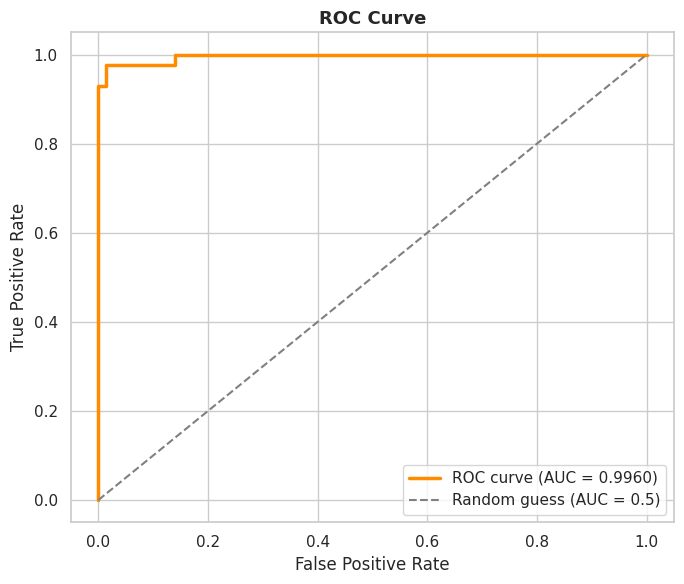

ROC-AUC: 0.9960


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2.5, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc:.4f}")


**Inference:** An AUC this close to 1.0 indicates the model separates Malignant from Benign cases almost perfectly across all thresholds — the 30 cell-nuclei measurements carry a very strong signal for this diagnosis task.

## 9. Threshold Tuning

The default 0.5 threshold isn't always optimal — especially in medicine, where **missing a malignant tumor (false negative) is far more costly than a false alarm (false positive)**. Lowering the threshold makes the model flag more cases as Malignant, **increasing recall** at the cost of precision. Let's examine that trade-off directly.

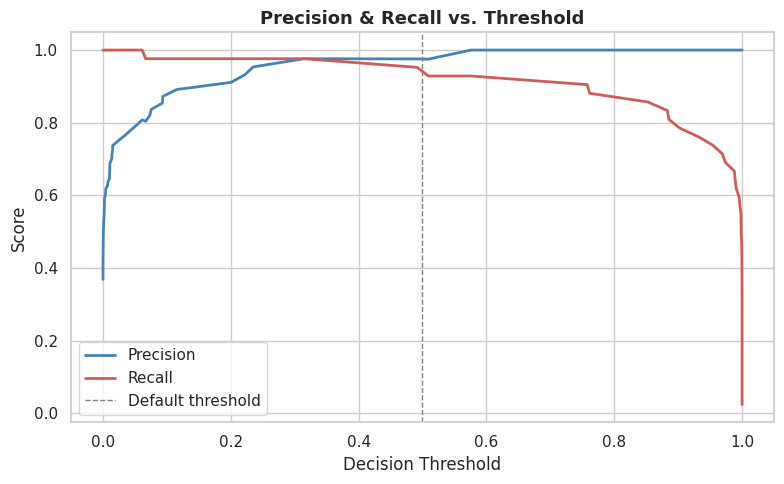

In [13]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(pr_thresholds, precisions[:-1], label='Precision', color='steelblue', linewidth=2)
plt.plot(pr_thresholds, recalls[:-1], label='Recall', color='indianred', linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs. Threshold', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Compare metrics at a few candidate thresholds
candidate_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []
for t in candidate_thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': round(precision_score(y_test, y_pred_t), 4),
        'recall': round(recall_score(y_test, y_pred_t), 4),
        'f1': round(f1_score(y_test, y_pred_t), 4),
        'false_negatives': int(((y_pred_t == 0) & (y_test == 1)).sum()),
        'false_positives': int(((y_pred_t == 1) & (y_test == 0)).sum()),
    })

results_df = pd.DataFrame(results)
results_df


,threshold,precision,recall,f1,false_negatives,false_positives
0,0.3,0.9762,0.9762,0.9762,1,1
1,0.4,0.9756,0.9524,0.9639,2,1
2,0.5,0.9750,0.9286,0.9512,3,1
3,0.6,1.0000,0.9048,0.9500,4,0
4,0.7,1.0000,0.9048,0.9500,4,0


**Inference:** Lowering the threshold below 0.5 (e.g., to 0.3) trades some precision for higher recall — reducing **false negatives** (missed malignant tumors), which is usually the clinically preferred trade-off. Raising the threshold does the opposite: fewer false alarms, but more missed cancers. The right choice depends on the relative cost of each error type in the real-world application — for cancer screening, minimizing false negatives is typically prioritized even at the expense of precision.

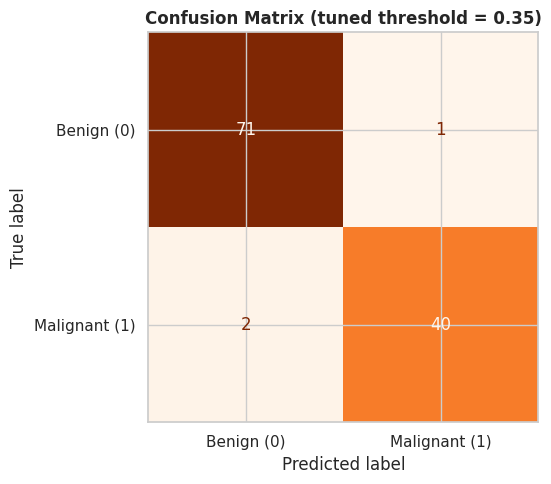

At threshold=0.35:
  Precision: 0.9756
  Recall:    0.9524
  F1-score:  0.9639


In [15]:
# Apply a lowered threshold (e.g. 0.35) chosen to favor recall, and show its confusion matrix
chosen_threshold = 0.35
y_pred_tuned = (y_proba >= chosen_threshold).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(5.5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
plt.title(f'Confusion Matrix (tuned threshold = {chosen_threshold})', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"At threshold={chosen_threshold}:")
print(f"  Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred_tuned):.4f}")


## 10. Feature Importance (Model Coefficients)

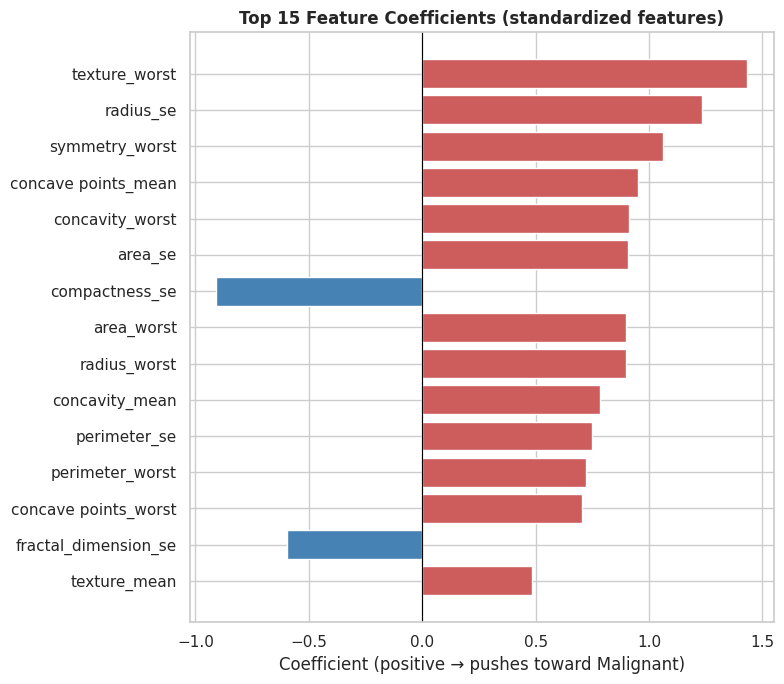

In [16]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(8,7))
colors = ['indianred' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients (standardized features)', fontweight='bold')
plt.xlabel('Coefficient (positive → pushes toward Malignant)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Inference:** Features like `concave points_worst`, `radius_worst`, and `texture_worst` (red bars) push predictions toward **Malignant** most strongly, while some features push toward Benign (blue bars). Since features were standardized, coefficient magnitude is directly comparable across features.

## 11. Summary

1. **Sigmoid function** converts the model's raw linear score into a probability between 0 and 1, enabling a natural probabilistic interpretation and a tunable decision threshold.
2. The model achieves a **very high ROC-AUC**, indicating strong separability between Benign and Malignant tumors from these 30 cell-nuclei features.
3. At the default 0.5 threshold, precision and recall are both strong, but a handful of false negatives remain.
4. **Threshold tuning** (lowering below 0.5) trades precision for recall — a clinically sensible choice when missing a malignant tumor is far costlier than a false alarm.
5. The **largest/"worst"-value features** (e.g., `concave points_worst`, `radius_worst`) are the strongest drivers of a malignant prediction.
